In [154]:
import numpy as np
import torch
import torch.nn
import time
import matplotlib.pyplot as plt
import math

In [58]:
print(torch.__version__)
print(torch.cuda.is_available())
# print(torch.cuda.get_device_name())

2.13.0+cpu
False


In [59]:
soumya_age = torch.tensor(23)
print(soumya_age.ndim)
print(soumya_age.shape)

0
torch.Size([])


In [60]:
# A scalar — just a number
scalar = torch.tensor(42.0)
print(f"Scalar: {scalar}")
print(f"  Shape: {scalar.shape}")      # torch.Size([])
print(f"  Dimensions: {scalar.dim()}")  # 0
print()

# A vector — a list of numbers
vector = torch.tensor([1.0, 2.0, 3.0, 4.0])
print(f"Vector: {vector}")
print(f"  Shape: {vector.shape}")      # torch.Size([4])
print(f"  Dimensions: {vector.dim()}")  # 1
print()

# A matrix — a grid of numbers
matrix = torch.tensor([[1, 2, 3],
                        [4, 5, 6]])
print(f"Matrix:\n{matrix}")
print(f"  Shape: {matrix.shape}")      # torch.Size([2, 3])
print(f"  Dimensions: {matrix.dim()}")  # 2
print()

# A 3D tensor — a cube of numbers
tensor_3d = torch.zeros(2, 3, 4)
print(f"3D Tensor shape: {tensor_3d.shape}")    # [2, 3, 4]
print(f"  Dimensions: {tensor_3d.dim()}")        # 3
print()

# A 4D tensor — like a batch going through multi-head attention
tensor_4d = torch.zeros(8, 12, 3, 64)
print(f"4D Tensor shape: {tensor_4d.shape}")    # [8, 12, 3, 64]
print(f"  That's: 8 sentences × 12 heads × 3 tokens × 64 dims")

Scalar: 42.0
  Shape: torch.Size([])
  Dimensions: 0

Vector: tensor([1., 2., 3., 4.])
  Shape: torch.Size([4])
  Dimensions: 1

Matrix:
tensor([[1, 2, 3],
        [4, 5, 6]])
  Shape: torch.Size([2, 3])
  Dimensions: 2

3D Tensor shape: torch.Size([2, 3, 4])
  Dimensions: 3

4D Tensor shape: torch.Size([8, 12, 3, 64])
  That's: 8 sentences × 12 heads × 3 tokens × 64 dims


In [61]:
z = torch.zeros(3, 4)
o = torch.ones(2, 5)
r = torch.randn(3,3) # randn -> random distribution 
r

tensor([[ 1.9365, -0.2592, -0.1451],
        [-1.7560, -0.6042, -0.1692],
        [ 2.1836,  1.2772, -1.5987]])

In [62]:
seq = torch.arange(0, 10)

In [63]:
lin = torch.linspace(0, 1, 5)

In [66]:
batch_size = 8   # No of sentences processed at a time
seq_len = 128    # No of words in a sentence
embed_dim = 768  # Embeddings
num_heads = 12   # 
head_dim = embed_dim // num_heads  # 64

In [76]:
# A batch of tokenized sentences
x = torch.randn(batch_size, seq_len, embed_dim)
print(f"Batch of sentences: {x.shape}")

x_heads = x.view(batch_size, seq_len, num_heads, head_dim)
print(f"After splitting into heads: {x_heads.shape}")
print(f"{batch_size} sentences, {seq_len} tokens, {num_heads} heads, {head_dim} dims per head")

Batch of sentences: torch.Size([8, 128, 768])
After splitting into heads: torch.Size([8, 128, 12, 64])
8 sentences, 128 tokens, 12 heads, 64 dims per head


In [83]:

# Rearrange so heads come before tokens (needed for attention)
x_ready = x_heads.permute(0, 2, 1, 3)
print(f"After permute for attention: {x_ready.shape}")
print(f"{batch_size} sentences, {num_heads} heads, {seq_len} tokens, {head_dim} dims")


After permute for attention: torch.Size([8, 12, 128, 64])
8 sentences, 12 heads, 128 tokens, 64 dims


In [91]:
# A vector pointing right
v = torch.tensor([1.0, 0.0])
print(f"Original vector: {v.tolist()}")

rotate_90 = torch.tensor([[0., -1.], [1.,  0.]])

rotated = rotate_90 @ v
print(f"After rotation: {rotated.tolist()}")  # [0, 1] → pointing up!

angle = math.radians(90)
rotate_45 = torch.tensor([[math.cos(angle), -math.sin(angle)], [math.sin(angle),  math.cos(angle)]])

rotated_45 = rotate_45 @ v
print(f"After 45° rotation: [{rotated_45[0]:.3f}, {rotated_45[1]:.3f}]")

Original vector: [1.0, 0.0]
After rotation: [0.0, 1.0]
After 45° rotation: [0.000, 1.000]


In [92]:
def plot_transformation(matrix, title="Transformation"):
    """Visualize how a 2x2 matrix transforms a grid of points."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Create a grid of points
    n = 10
    x = np.linspace(-2, 2, n)
    y = np.linspace(-2, 2, n)

    # Plot original grid
    ax = axes[0]
    ax.set_title("Original", fontsize=14, fontweight='bold')
    for xi in x:
        ax.plot([xi]*n, y, 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        ax.plot(x, [yi]*n, 'b-', alpha=0.3, linewidth=1)

    # Highlight a square
    square_x = [0, 1, 1, 0, 0]
    square_y = [0, 0, 1, 1, 0]
    ax.plot(square_x, square_y, 'r-', linewidth=3)

    # Arrow for basis vectors
    ax.annotate('', xy=(1, 0), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=(0, 1), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    # Plot transformed grid
    M = np.array(matrix)
    ax = axes[1]
    ax.set_title(f"{title}", fontsize=14, fontweight='bold')

    for xi in x:
        points = np.array([[xi, yi] for yi in y])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)
    for yi in y:
        points = np.array([[xi, yi] for xi in x])
        transformed = (M @ points.T).T
        ax.plot(transformed[:, 0], transformed[:, 1], 'b-', alpha=0.3, linewidth=1)

    # Transform the square
    sq = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]]).T
    sq_t = M @ sq
    ax.plot(sq_t[0], sq_t[1], 'r-', linewidth=3)

    # Transform basis vectors
    e1_t = M @ np.array([1, 0])
    e2_t = M @ np.array([0, 1])
    ax.annotate('', xy=e1_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
    ax.annotate('', xy=e2_t, xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='purple', lw=2.5))

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)

    plt.tight_layout()
    plt.show()

print("✅ Visualization function ready! Run the cells below.")

✅ Visualization function ready! Run the cells below.


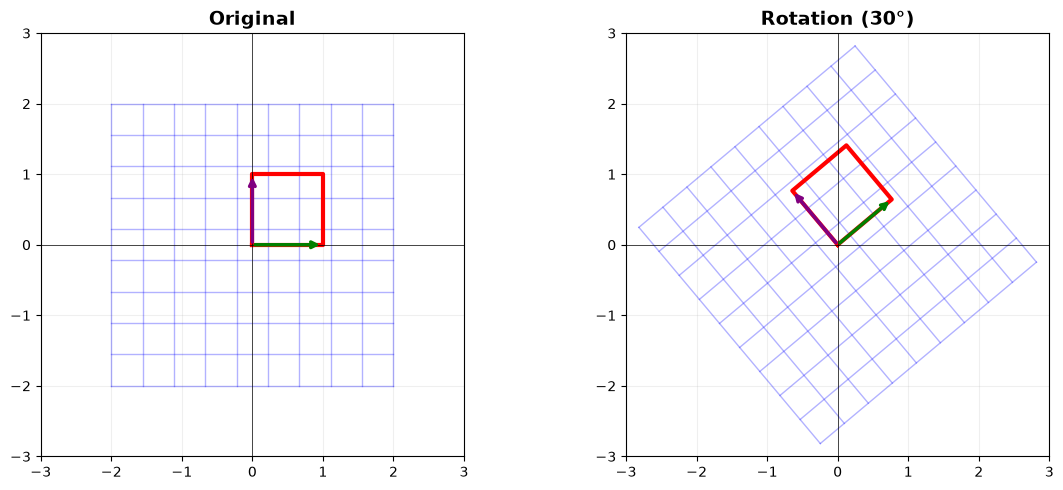

In [94]:
# 🔥 ROTATION — the grid spins!
angle = math.radians(40)
rotation = [[math.cos(angle), -math.sin(angle)],
            [math.sin(angle),  math.cos(angle)]]
plot_transformation(rotation, "Rotation (30°)")

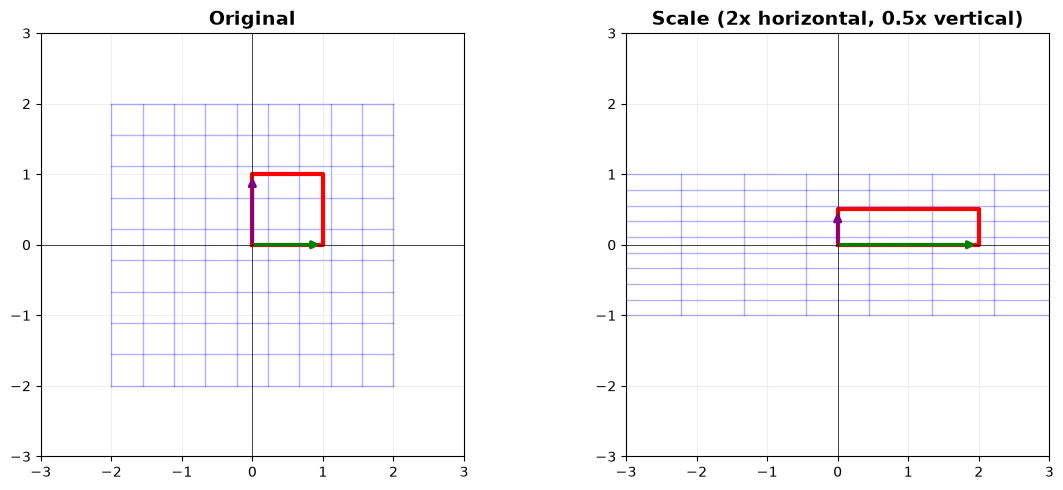

In [95]:
# 🔥 SCALING — stretch and squish!
plot_transformation([[2, 0], [0, 0.5]], "Scale (2x horizontal, 0.5x vertical)")

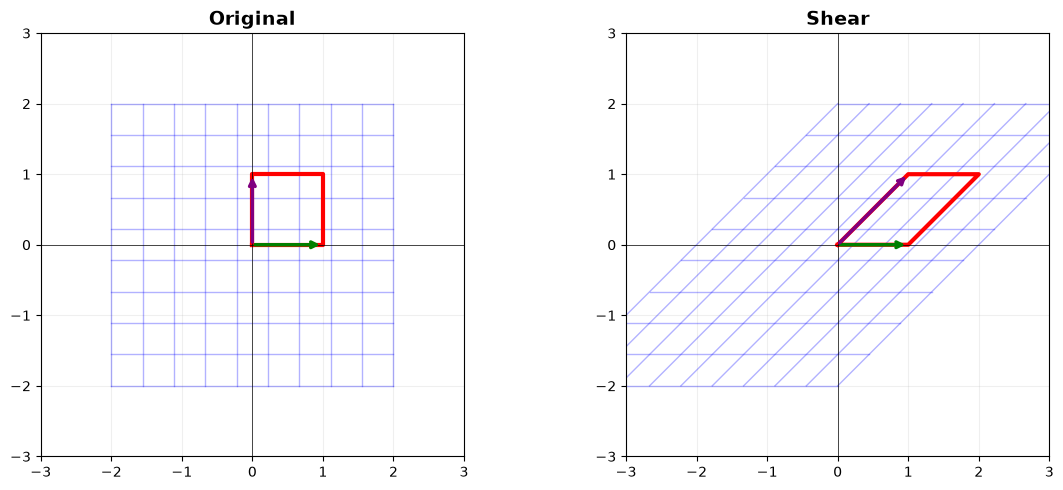

In [96]:
# 🔥 SHEAR — lean it sideways!
plot_transformation([[1, 1], [0, 1]], "Shear")

In [98]:
# Two similar vectors (pointing roughly the same way)
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([1.1, 1.9, 3.1])
print(f"Similar vectors dot product: {a @ b:.2f}")  # high!

# Two perpendicular vectors
c = torch.tensor([1.0, 0.0])
d = torch.tensor([0.0, 1.0])
print(f"Perpendicular dot product:   {c @ d:.2f}")  # zero!

# Two opposite vectors
e = torch.tensor([1.0, 2.0])
f = torch.tensor([-1.0, -2.0])
print(f"Opposite vectors dot product: {e @ f:.2f}")  # negative!


Similar vectors dot product: 14.20
Perpendicular dot product:   0.00
Opposite vectors dot product: -5.00


In [ ]:
# Multiply two matrices using Python loops (the slow way)
def matmul_slow(A, B):
    rows_A, cols_A = A.shape
    rows_B, cols_B = B.shape
    C = torch.zeros(rows_A, cols_B)
    for i in range(rows_A):
        for j in range(cols_B):
            for k in range(cols_A):
                C[i][j] += A[i][k] * B[k][j]
    return C

size = 100
A = torch.randn(size, size)
B = torch.randn(size, size)

# Slow way
start = time.time()
C_slow = matmul_slow(A, B)
slow_time = time.time() - start

# Fast way (PyTorch optimized)
start = time.time()
C_fast = A @ B
fast_time = time.time() - start

print(f"Matrix multiply {size}×{size}:")
print(f"  Python loops: {slow_time:.4f} seconds")
print(f"  PyTorch @:    {fast_time:.6f} seconds")
print(f"  Speedup:      {slow_time/fast_time:.0f}x faster! 🚀")
print()

In [101]:
# Basic math — element-wise
a = torch.tensor([1.0, 2.0, 3.0])
b = torch.tensor([4.0, 5.0, 6.0])

print("Element-wise operations:")
print(f"  a + b = {a + b}")
print(f"  a * b = {a * b}")      # element-wise multiply
print(f"  a @ b = {a @ b}")      # dot product!
print()

# Broadcasting in action
matrix = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
bias = torch.tensor([10.0, 20.0, 30.0])

result = matrix + bias  # bias gets added to EVERY row
print("Broadcasting:")
print(f"  Matrix shape: {matrix.shape}")
print(f"  Bias shape:   {bias.shape}")
print(f"  Result:\n{result}")
print("  Bias was added to both rows automatically!")
print()

# Useful operations
x = torch.randn(3, 4)
print(f"Random tensor:\n{x}\n")
print(f"  Mean:    {x.mean():.4f}")
print(f"  Std:     {x.std():.4f}")
print(f"  Max:     {x.max():.4f}")
print(f"  Argmax:  {x.argmax()} (index of largest element)")
print(f"  Softmax: {torch.softmax(x[0], dim=0)}")
print(f"  ☝️ Softmax turns values into probabilities (sums to 1)")

Element-wise operations:
  a + b = tensor([5., 7., 9.])
  a * b = tensor([ 4., 10., 18.])
  a @ b = 32.0

Broadcasting:
  Matrix shape: torch.Size([2, 3])
  Bias shape:   torch.Size([3])
  Result:
tensor([[11., 22., 33.],
        [14., 25., 36.]])
  Bias was added to both rows automatically!

Random tensor:
tensor([[ 1.4399, -1.1169, -2.8850,  1.1884],
        [-0.2498,  0.1182,  0.8415, -0.6510],
        [ 0.5187, -0.7319,  0.8670, -0.0659]])

  Mean:    -0.0606
  Std:     1.1978
  Max:     1.4399
  Argmax:  0 (index of largest element)
  Softmax: tensor([0.5352, 0.0415, 0.0071, 0.4162])
  ☝️ Softmax turns values into probabilities (sums to 1)


In [108]:
x = torch.tensor(3.0, requires_grad=True)  # ← "enables us to track gradient(derivative finding)"
y = x**2 + 2*x + 1 
print(f"x = {x}")
print(f"y = x² + 2x + 1 = {y}")

y.backward()

print(f"dy/dx = {x.grad}")
print(f"Check: dy/dx = 2x + 2 = 2(3) + 2 = {2*3 + 2} ✓")
print()
print("🤯 PyTorch computed the derivative automatically!")

x = 3.0
y = x² + 2x + 1 = 16.0
dy/dx = 8.0
Check: dy/dx = 2x + 2 = 2(3) + 2 = 8 ✓

🤯 PyTorch computed the derivative automatically!


In [112]:
x = torch.tensor(2.0, requires_grad=True)

# A more complex function
y = torch.sin(x) * torch.exp(x) + x**3

y.backward()

print(f"f(x) = sin(x) × eˣ + x³")
print(f"f(2) = {y:.4f}")
print(f"f'(2) = {x.grad:.4f}")
print()


f(x) = sin(x) × eˣ + x³
f(2) = 14.7188
f'(2) = 15.6439



In [155]:
# This is what actually happens during training
W = torch.randn(3, 2, requires_grad=True)  # a weight matrix
x = torch.tensor([1.0, 0.5])                # input
target = torch.tensor([1.0, 0.0, 0.0])      # target output

# Forward pass
prediction = W @ x                    # matrix × vector
loss = ((prediction - target)**2).sum()  # MSE loss

print(f"Weight matrix W:\n{W.data}")
print(f"Input: {x}")
print(f"Prediction: {prediction.data}")
print(f"Target: {target}")
print(f"Loss: {loss.item():.4f}")
print()

# Backward pass — gradients for EVERY element of W
loss.backward()

print(f"Gradients for W (∂Loss/∂W):\n{W.grad}")
print()
print("☝️ PyTorch computed the gradient for all 6 weights at once!")
print("   This is what happens billions of times during training.")

Weight matrix W:
tensor([[-0.2792,  0.7255],
        [-0.5818, -2.1117],
        [-1.4193, -1.4249]])
Input: tensor([1.0000, 0.5000])
Prediction: tensor([ 0.0835, -1.6376, -2.1318])
Target: tensor([1., 0., 0.])
Loss: 8.0661

Gradients for W (∂Loss/∂W):
tensor([[-1.8329, -0.9165],
        [-3.2752, -1.6376],
        [-4.2635, -2.1318]])

☝️ PyTorch computed the gradient for all 6 weights at once!
   This is what happens billions of times during training.


In [156]:
W = torch.tensor([
    [9., 8., 7., 6., 3., 3.],
    [9., 8., 7., 6., 3., 5.]
], requires_grad=True)

X = torch.tensor([19., 28., 37., 46., 53., 63.])
y = torch.tensor([16., 18.])
op = W @ X

LOSS = ((op - y) ** 2).sum()
LOSS.backward()
print(op)
print(W.grad)



tensor([1278., 1404.], grad_fn=<MvBackward0>)
tensor([[ 47956.,  70672.,  93388., 116104., 133772., 159012.],
        [ 52668.,  77616., 102564., 127512., 146916., 174636.]])


In [157]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_data = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_data = datasets.MNIST('./data', train=False, transform=transform)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1000)


In [158]:
class DigitClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()             # 28×28 → 784
        self.layer1 = nn.Linear(784, 256)       # 784 → 256 (learned transformation!)
        self.layer2 = nn.Linear(256, 128)       # 256 → 128 (another transformation!)
        self.layer3 = nn.Linear(128, 10)        # 128 → 10 digits (final transformation!)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)                # reshape image to vector
        x = self.relu(self.layer1(x))      # transform → activate
        x = self.relu(self.layer2(x))      # transform → activate
        x = self.layer3(x)                 # final transform → 10 scores
        return x

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = DigitClassifier().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:")
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")
print(f"  layer1: 784×256 matrix + 256 bias = {784*256 + 256:,} params")
print(f"  layer2: 256×128 matrix + 128 bias = {256*128 + 128:,} params")
print(f"  layer3: 128×10  matrix + 10  bias = {128*10 + 10:,} params")
print(f"\nAll parameters are MATRICES (+ biases).")
print(f"Training = finding the right transformations.")
print(f"Device: {device}")
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

# Track progress
train_losses = []
train_accs = []
test_accs = []

print("\n🔥 TRAINING STARTS NOW!\n")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Train Acc':>9} | {'Test Acc':>8} | {'Time':>6}")
print("-" * 55)

for epoch in range(5):
    # --- Training ---
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0
    start = time.time()

    for batch_x, batch_y in train_loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # THE 5-LINE TRAINING LOOP!
        predictions = model(batch_x)          # 1. Forward pass
        loss = loss_fn(predictions, batch_y)   # 2. Compute loss
        loss.backward()                        # 3. Backward pass
        optimizer.step()                       # 4. Update weights
        optimizer.zero_grad()                  # 5. Reset gradients

        epoch_loss += loss.item()
        correct += (predictions.argmax(1) == batch_y).sum().item()
        total += len(batch_y)

    train_loss = epoch_loss / len(train_loader)
    train_acc = correct / total

    # --- Testing ---
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            preds = model(batch_x)
            correct += (preds.argmax(1) == batch_y).sum().item()
            total += len(batch_y)

    test_acc = correct / total
    elapsed = time.time() - start

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"  {epoch+1:>3}  | {train_loss:>10.4f} | {train_acc:>8.1%} | {test_acc:>7.1%} | {elapsed:>5.1f}s")

print(f"\n🎉 Final test accuracy: {test_accs[-1]:.1%}")
print(f"   The model learned to recognize handwritten digits!")

NameError: name 'nn' is not defined